In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
spectrum_1 = pd.read_csv("Spectrum2s_1_noreg_gas_exp.csv")
spectrum_2 = pd.read_csv("Spectrum2s_2_noreg_gas_exp.csv")
spectrum_3 = pd.read_csv("Spectrum2s_3_noreg_gas_exp.csv")

In [4]:
spectrum_2

,Name,Flux,Error_flux
0,Hbeta,55.700969,2.895524
1,Halpha,211.970102,9.379774
2,[SII]6716,19.075112,0.408020
3,[SII]6731,15.046348,0.883896
4,HeII4687,0.418560,0.045740
5,HeI5876,8.216447,0.323237
6,[OIII]4959,42.202466,2.437554
7,[OIII]5007,126.607397,2.437554
8,[OI]6300,1.293895,0.159569
9,[OI]6364,0.431298,0.159569


In [5]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    e_1 = err_1/(flux_1*np.log(10))
    e_2 = err_2/(flux_2*np.log(10))
    print(np.sqrt((e_1)**2+(e_2)**2))
    return np.sqrt((e_1)**2+(e_2)**2)
    
def ratio(spectrum):
    OIII_HB = spectrum['Flux'][7]/spectrum['Flux'][0]
    NII_HA = spectrum['Flux'][11]/spectrum['Flux'][1]
    SII_HA = spectrum['Flux'][2]/spectrum['Flux'][1]
    err_OIII_HB = error_ratio(spectrum['Error_flux'][7], spectrum['Error_flux'][0], spectrum['Flux'][7], spectrum['Flux'][0])
    err_NII_HA = error_ratio(spectrum['Error_flux'][11], spectrum['Error_flux'][1], spectrum['Flux'][11], spectrum['Flux'][1])
    err_SII_HA = error_ratio(spectrum['Error_flux'][2], spectrum['Error_flux'][1], spectrum['Flux'][2], spectrum['Flux'][1]) 
    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

0.02313318987177226
0.03658188025288772
0.019317024211133606
0.02407473401863592
0.03238599487522796
0.021345218207461332
0.022929631492444875
0.037282748958342195
0.022165500450830083


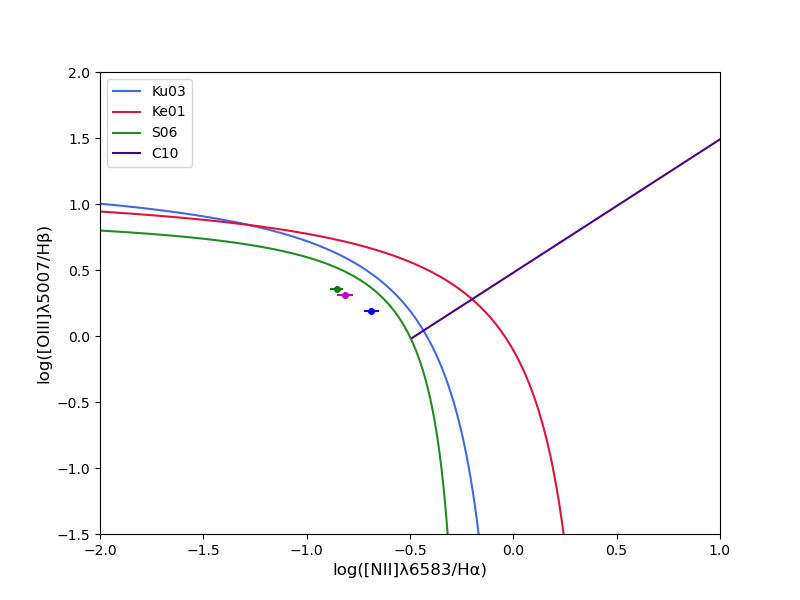

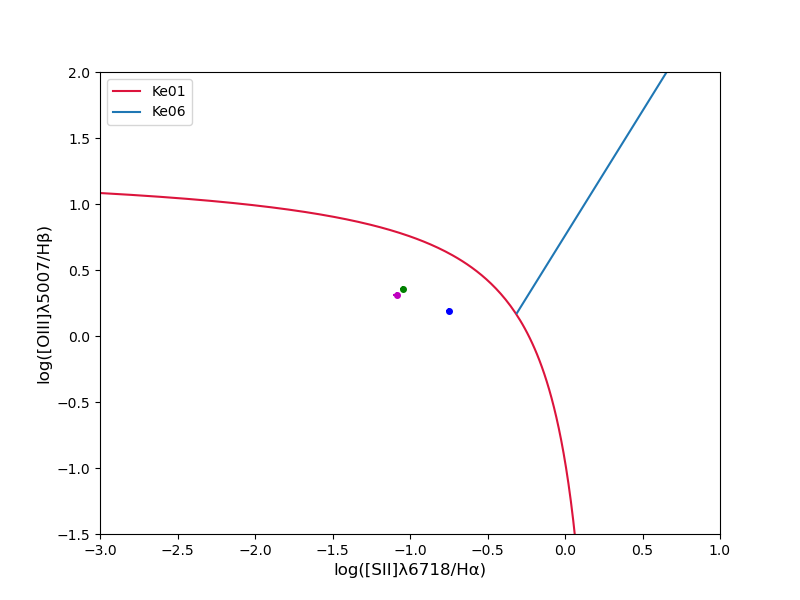

In [6]:
plt.figure(figsize=(8,6))

OIII_HB_1, NII_HA_1, SII_HA_1, err_OIII_HB_1, err_NII_HA_1, err_SII_HA_1 = ratio(spectrum_1)
OIII_HB_2, NII_HA_2, SII_HA_2, err_OIII_HB_2, err_NII_HA_2, err_SII_HA_2 = ratio(spectrum_2)
OIII_HB_3, NII_HA_3, SII_HA_3, err_OIII_HB_3, err_NII_HA_3, err_SII_HA_3 = ratio(spectrum_3)

plt.errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
plt.plot(x3, C10(x3), label = 'C10', color = 'indigo')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_2s', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')

x = np.linspace(-3, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-3, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_2s', bbox_inches='tight')

## BPT con correzioni

In [7]:
areas_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/Contaminations/Areas_OIII_2s.csv",
                        index_col = 0)
areas_NII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/Contaminations/Areas_NII_2s.csv",
                        index_col = 0)
areas_SII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/Contaminations/Areas_SII_2s.csv",
                        index_col = 0)
areas_Halpha = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/Contaminations/Areas_Halpha_2s.csv",
                        index_col = 0)
areas_Hbeta = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3773/Contaminations/Areas_Hbeta_2s.csv",
                        index_col = 0)

In [8]:
areas_SII

,Peak 1,Peak 2,Peak 3
Blue,79.475,29.030,6.073
Green,19.436,57.264,13.874
Purple,1.089,13.706,80.053


In [9]:
areas_SII['Peak 1'].iloc[0]

79.475

In [10]:
def true_flux(spectrum, spectrum2, spectrum3, area, e_1, e_2, e_3):
    riga_1 = spectrum*area['Peak 1'].iloc[0]/100
    err_1 = e_1*area['Peak 1'].iloc[0]/100
    riga_2 = spectrum2*area['Peak 2'].iloc[1]/100
    err_2 = e_2*area['Peak 2'].iloc[1]/100
    riga_3 = spectrum3*area['Peak 3'].iloc[2]/100
    err_3 = e_3*area['Peak 3'].iloc[2]/100
   # riga_4 = spectrum4*area['Peak 4'].iloc[3]/100
   # err_4 = e_4*area['Peak 4'].iloc[3]/100
    return riga_1, riga_2, riga_3, err_1, err_2, err_3 #, err_4

In [11]:
OIII_1, OIII_2, OIII_3, err_OIII_1, err_OIII_2, err_OIII_3 = true_flux(spectrum_1['Flux'][7], spectrum_2['Flux'][7], 
                                                                        spectrum_3['Flux'][7], areas_OIII,spectrum_1['Error_flux'][7],
                                                                       spectrum_2['Error_flux'][7], spectrum_3['Error_flux'][7])
HB_1, HB_2, HB_3, err_HB_1, err_HB_2, err_HB_3 =true_flux(spectrum_1['Flux'][0], spectrum_2['Flux'][0], 
                                                    spectrum_3['Flux'][0], areas_Hbeta,
                                                    spectrum_1['Error_flux'][0], spectrum_2['Error_flux'][0], 
                                                    spectrum_3['Error_flux'][0])
HA_1, HA_2, HA_3, err_HA_1, err_HA_2, err_HA_3 = true_flux(spectrum_1['Flux'][1], spectrum_2['Flux'][1], 
                                                    spectrum_3['Flux'][1], areas_Halpha,
                                                    spectrum_1['Error_flux'][1], spectrum_2['Error_flux'][1], 
                                                    spectrum_3['Error_flux'][1])
NII_1, NII_2, NII_3, err_NII_1, err_NII_2, err_NII_3 = true_flux(spectrum_1['Flux'][11], spectrum_2['Flux'][11], 
                                                    spectrum_3['Flux'][11], areas_NII,
                                                    spectrum_1['Error_flux'][11], spectrum_2['Error_flux'][11], 
                                                    spectrum_3['Error_flux'][11])
SII_1, SII_2, SII_3, err_SII_1, err_SII_2, err_SII_3 = true_flux(spectrum_1['Flux'][2], spectrum_2['Flux'][2], 
                                                    spectrum_3['Flux'][2], areas_SII,
                                                    spectrum_1['Error_flux'][2], spectrum_2['Error_flux'][2], 
                                                    spectrum_3['Error_flux'][2])

0.02313318987177226
0.03658188025288772
0.01931702421113361
0.024074734018635923
0.03238599487522796
0.02134521820746133
0.022929631492444875
0.03728274895834219
0.022165500450830086


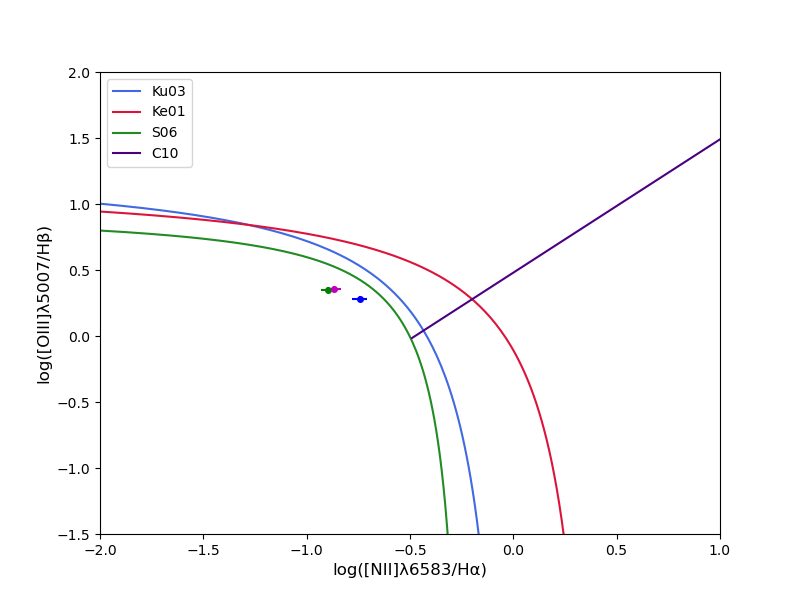

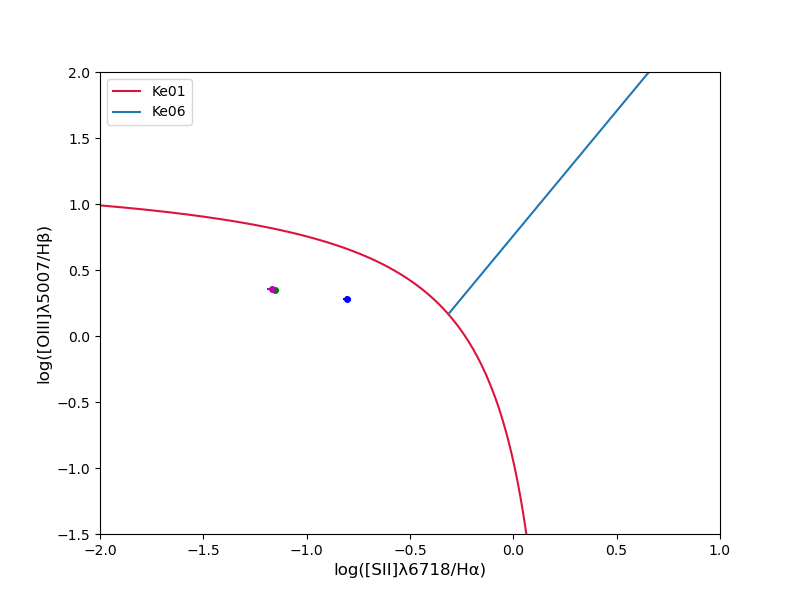

In [12]:
 plt.figure(figsize=(8,6))

OIII_HB_1_true = OIII_1/HB_1
NII_HA_1_true = NII_1/HA_1
SII_HA_1_true = SII_1/HA_1
err_OIII_HB_1_true = error_ratio(err_OIII_1, err_HB_1, OIII_1, HB_1)
err_NII_HA_1_true = error_ratio(err_NII_1, err_HA_1, NII_1, HA_1)
err_SII_HA_1_true = error_ratio(err_SII_1, err_HA_1, SII_1, HA_1)

OIII_HB_2_true = OIII_2/HB_2
NII_HA_2_true = NII_2/HA_2
SII_HA_2_true = SII_2/HA_2
err_OIII_HB_2_true = error_ratio(err_OIII_2, err_HB_2, OIII_2, HB_2)
err_NII_HA_2_true = error_ratio(err_NII_2, err_HA_2, NII_2, HA_2)
err_SII_HA_2_true = error_ratio(err_SII_2, err_HA_2, SII_2, HA_2)

OIII_HB_3_true = OIII_3/HB_3
NII_HA_3_true = NII_3/HA_3
SII_HA_3_true = SII_3/HA_3
err_OIII_HB_3_true = error_ratio(err_OIII_3, err_HB_3, OIII_3, HB_3)
err_NII_HA_3_true = error_ratio(err_NII_3, err_HA_3, NII_3, HA_3)
err_SII_HA_3_true = error_ratio(err_SII_3, err_HA_3, SII_3, HA_3)

plt.errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
plt.plot(x3, C10(x3), label = 'C10', color = 'indigo')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_2s_true', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_2s_true', bbox_inches='tight')

In [13]:
np.log10(SII_HA_1_true)

-0.8030161534352337

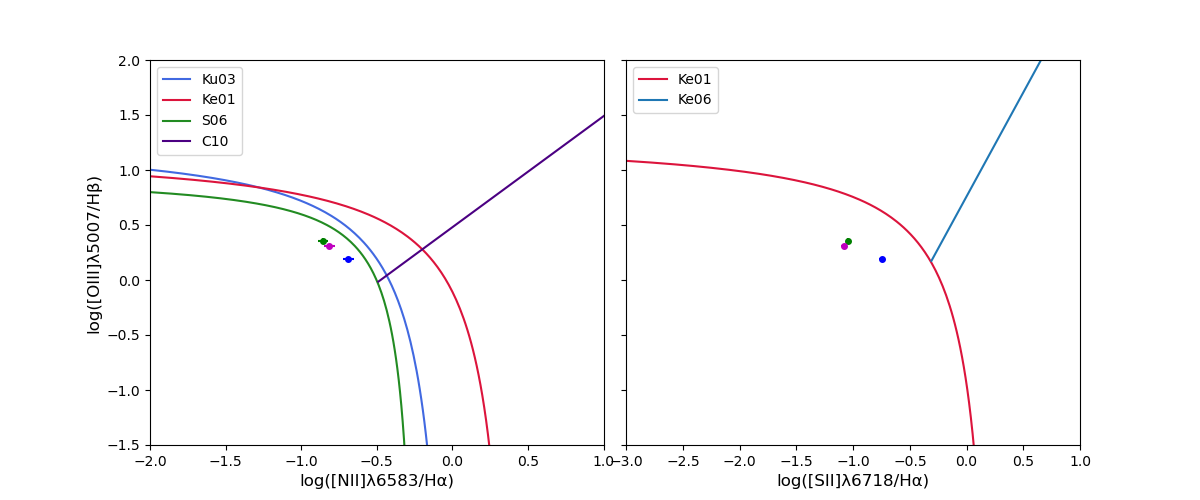

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y =np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2), y =np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3), y =np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4), y =np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-3, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-3, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_2s_both.png', bbox_inches='tight')

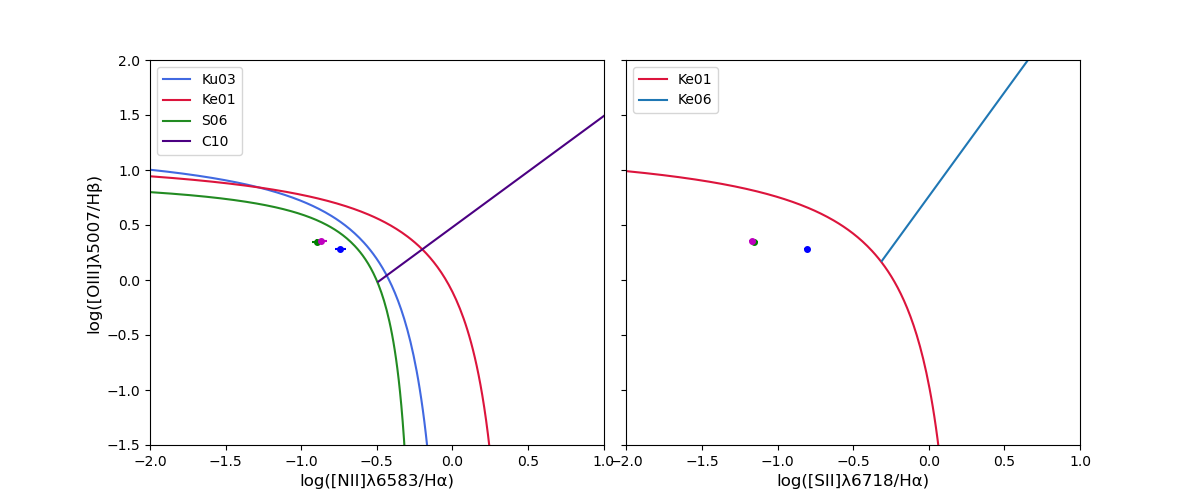

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_2s_both_true.png', bbox_inches='tight')

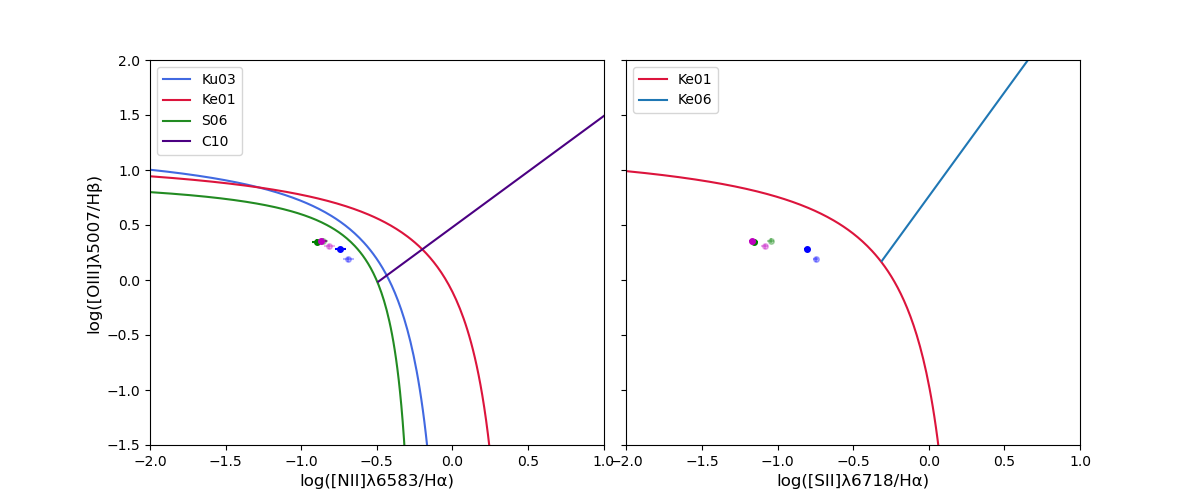

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
#ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y =np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_2), y =np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_3), y =np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
#ax[1].errorbar(x = np.log10(SII_HA_4), y =np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_2s_motion.png', bbox_inches='tight')